# V-Dem × ILO × Gini × Education Panel for Post-1990 Democratizers (1990–2022)

This notebook demonstrates the dataset construction pipeline from **`data.py`**.

## What this artifact does

`data.py` converts a merged panel of four authoritative data sources into a structured example dataset:

- **V-Dem v15** — liberal democracy index and sub-indices (judicial constraints, civil liberties, polyarchy, etc.)
- **ILO ILOSTAT SDG 1.3.1** — effective social protection coverage (available 2015+)
- **SWIID** — LIS-standardized Gini inequality (disposable and market)
- **OWID/Barro-Lee/UNDP** — mean years of schooling (forward-filled from 2017)

The script selects 96 post-1990 democratizer countries over 5-year periods (1990–2022) and produces the **`vdem_ilo_gini_edu_panel_complete`** dataset: 161 country-period rows where all four core variables are simultaneously non-null — the directly usable analysis sample for a differences-in-differences (DD) triple-interaction estimator.

**Task type**: Regression  
**Target variable**: `v2x_libdem` (V-Dem Liberal Democracy Index, 0–1 scale)


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core scientific packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'scipy==1.16.3')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (from original data.py) ---
import json
import sys
from pathlib import Path

from loguru import logger

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")


1

In [3]:
# --- Data loading helper ---
# Loads from GitHub (Colab) with fallback to local file
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-395f4e-education-inequality-and-democratic-eros/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

import os


In [4]:
data = load_data()
logger.info(f"Loaded {len(data['datasets'])} dataset(s)")


10:51:07|INFO   |Loaded 1 dataset(s)


## Configuration

Tunable parameters. Set to minimum values here for a fast demo run; comment in the originals for a full run.


In [5]:
# --- Config ---

# Maximum examples to process from the dataset (None = all)
# Minimum for demo: 2  |  Full original: None
N_EXAMPLES = None  # use all available in mini dataset (3 examples)

# Dataset name to select from the loaded JSON
DATASET_NAME = "vdem_ilo_gini_edu_panel_complete"

# Core variables that must all be non-null (from original script)
CORE_VARS = ["v2x_libdem", "socprot_coverage", "education", "gini_disp"]

# Target variable
TARGET = "v2x_libdem"

# Input feature columns (from original data.py INPUT_FEATURES)
INPUT_FEATURES = [
    "country_iso3", "period", "period_start", "period_end",
    "v2x_jucon", "v2jucomp", "v2cseeorgs", "v2csprtcpt",
    "v2x_civlib", "v2xcl_rol", "v2x_polyarchy",
    "education", "gini_disp", "gini_mkt", "gini_disp_se",
    "socprot_coverage", "directly_reported_any", "directly_reported_all",
    "mean_education", "mean_gini_disp", "mean_socprot_coverage",
    "e_education", "e_gini_disp", "e_socprot_coverage",
    "education_imputed",
]


## Dataset Structure

Each example in the dataset has:
- **`input`**: JSON string of 25 features (V-Dem sub-indices, education, Gini, social protection coverage, within-country deviations for DD estimation)
- **`output`**: V-Dem Liberal Democracy Index (target, 0–1)
- **`metadata_*`**: row index, country name, task type, target variable name, democratizer flag, completeness flag

Here we parse the examples into a flat DataFrame for inspection.


In [6]:
# --- Select dataset and slice examples (per config) ---
dataset_obj = next(d for d in data["datasets"] if d["dataset"] == DATASET_NAME)
examples = dataset_obj["examples"]
if N_EXAMPLES is not None:
    examples = examples[:N_EXAMPLES]
logger.info(f"Dataset '{DATASET_NAME}': {len(examples)} examples")

# Parse each example's input JSON string into a flat dict (reverse of make_examples)
rows = []
for ex in examples:
    features = json.loads(ex["input"])
    features[TARGET] = float(ex["output"]) if ex["output"] != "null" else None
    features["country_name"] = ex["metadata_country_name"]
    features["has_all_core_vars"] = ex["metadata_has_all_core_vars"]
    rows.append(features)

df = pd.DataFrame(rows)
logger.info(f"DataFrame shape: {df.shape}")
df.head()


10:51:07|INFO   |Dataset 'vdem_ilo_gini_edu_panel_complete': 3 examples


10:51:07|INFO   |DataFrame shape: (3, 28)


,country_iso3,period,period_start,period_end,v2x_jucon,v2jucomp,v2cseeorgs,v2csprtcpt,v2x_civlib,v2xcl_rol,...,mean_education,mean_gini_disp,mean_socprot_coverage,e_education,e_gini_disp,e_socprot_coverage,education_imputed,v2x_libdem,country_name,has_all_core_vars
0,ALB,2020-22,2020,2022,0.725667,1.022333,1.7620,1.420333,0.888000,0.913000,...,9.095143,36.325556,78.10,0.904857,-1.392222,0.00,True,0.437000,Albania,True
1,ARG,2015-19,2015,2019,0.725400,0.925800,2.0338,2.462000,0.882200,0.853200,...,9.206095,41.817143,65.65,0.660571,-3.837143,-0.25,False,0.618400,Argentina,True
2,ARG,2020-22,2020,2022,0.766667,1.534333,1.7170,2.462000,0.877667,0.842667,...,9.206095,41.817143,65.65,0.693904,-3.817143,0.25,True,0.648333,Argentina,True


## Core Pipeline: `make_examples()`

The original `data.py` `make_examples()` function converts raw panel records into the structured `{input, output, metadata}` format. Below is the function copied directly from the script, followed by a demonstration run on our loaded records.


In [7]:
# --- make_examples() — copied verbatim from data.py ---
def make_examples(records: list[dict], dataset_name: str) -> dict:
    examples = []
    for i, row in enumerate(records):
        target_val = row.get(TARGET)
        output_str = str(round(target_val, 6)) if target_val is not None else "null"
        features = {k: row.get(k) for k in INPUT_FEATURES}
        has_all_core = all(row.get(v) is not None for v in CORE_VARS)
        examples.append({
            "input": json.dumps(features, separators=(",", ":")),
            "output": output_str,
            "metadata_row_index": i,
            "metadata_country_name": row.get("country_name"),
            "metadata_task_type": "regression",
            "metadata_target_variable": TARGET,
            "metadata_is_democratizer": row.get("is_democratizer"),
            "metadata_has_all_core_vars": has_all_core,
        })
    logger.info(f"Dataset '{dataset_name}': {len(examples)} examples")
    return {"dataset": dataset_name, "examples": examples}


## Complete-Case Filtering

The original script filters for the **complete analysis sample**: only rows where all four core variables (`v2x_libdem`, `socprot_coverage`, `education`, `gini_disp`) are simultaneously non-null.

This is the critical step — ILO social protection data is only available from 2015, so most pre-2015 rows are dropped here.


In [8]:
# --- Complete-case filtering — from data.py main() ---
# df contains the parsed records; apply the same core-var completeness filter
records = df.to_dict(orient="records")
complete = [r for r in records if all(r.get(v) is not None for v in CORE_VARS)]
logger.info(f"Complete-case records: {len(complete)}")

# Run make_examples on the complete-case records
ds_complete = make_examples(complete, DATASET_NAME)
logger.info(f"Output: {len(ds_complete['examples'])} examples in dataset '{ds_complete['dataset']}'")

# Show a sample example
sample = ds_complete["examples"][0]
print("\n--- Sample example (first record) ---")
print(f"  country:  {sample['metadata_country_name']}")
print(f"  output:   {sample['output']}  (v2x_libdem)")
print(f"  has_all_core_vars: {sample['metadata_has_all_core_vars']}")
print(f"  input keys: {list(json.loads(sample['input']).keys())}")


10:51:07|INFO   |Complete-case records: 3


10:51:07|INFO   |Dataset 'vdem_ilo_gini_edu_panel_complete': 3 examples


10:51:07|INFO   |Output: 3 examples in dataset 'vdem_ilo_gini_edu_panel_complete'



--- Sample example (first record) ---
  country:  Albania
  output:   0.437  (v2x_libdem)
  has_all_core_vars: True
  input keys: ['country_iso3', 'period', 'period_start', 'period_end', 'v2x_jucon', 'v2jucomp', 'v2cseeorgs', 'v2csprtcpt', 'v2x_civlib', 'v2xcl_rol', 'v2x_polyarchy', 'education', 'gini_disp', 'gini_mkt', 'gini_disp_se', 'socprot_coverage', 'directly_reported_any', 'directly_reported_all', 'mean_education', 'mean_gini_disp', 'mean_socprot_coverage', 'e_education', 'e_gini_disp', 'e_socprot_coverage', 'education_imputed']


## Results: Key Variable Distributions

The four core variables drive the DD triple-interaction estimator. Below we visualize their values across available country-period observations.


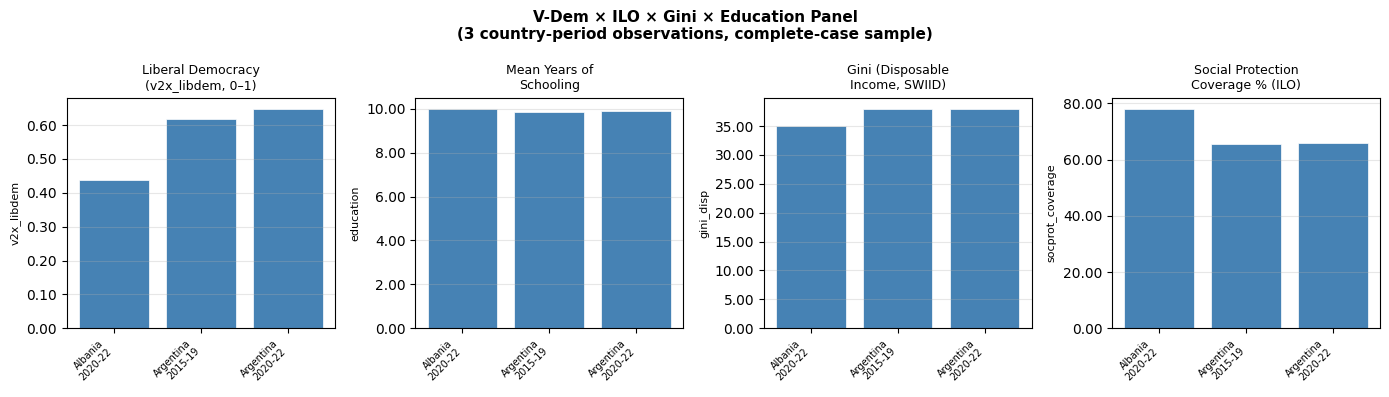


--- Core variable summary ---
 Liberal Democracy\n(v2x_libdem, 0–1)  Mean Years of\nSchooling  Gini (Disposable\nIncome, SWIID)  Social Protection\nCoverage % (ILO) country_name  period
                             0.437000                 10.000000                         34.933333                                 78.1      Albania 2020-22
                             0.618400                  9.866666                         37.980000                                 65.4    Argentina 2015-19
                             0.648333                  9.900000                         38.000000                                 65.9    Argentina 2020-22


In [9]:
# --- Visualization: key variables across country-period observations ---
core_numeric = ["v2x_libdem", "education", "gini_disp", "socprot_coverage"]
labels = {
    "v2x_libdem":       "Liberal Democracy\n(v2x_libdem, 0–1)",
    "education":        "Mean Years of\nSchooling",
    "gini_disp":        "Gini (Disposable\nIncome, SWIID)",
    "socprot_coverage": "Social Protection\nCoverage % (ILO)",
}

df_complete = pd.DataFrame(complete)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle(
    f"V-Dem × ILO × Gini × Education Panel\n"
    f"({len(df_complete)} country-period observations, complete-case sample)",
    fontsize=11, fontweight="bold"
)

for ax, col in zip(axes, core_numeric):
    vals = df_complete[col].dropna()
    countries = df_complete.loc[df_complete[col].notna(), "country_name"].tolist()
    periods   = df_complete.loc[df_complete[col].notna(), "period"].tolist()
    x_labels  = [f"{c}\n{p}" for c, p in zip(countries, periods)]

    ax.bar(range(len(vals)), vals, color="steelblue", edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha="right")
    ax.set_title(labels[col], fontsize=9)
    ax.set_ylabel(col, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary table ---
print("\n--- Core variable summary ---")
summary = df_complete[core_numeric + ["country_name", "period"]].rename(columns=labels)
print(summary.to_string(index=False))
